# Stage 5: Association rules

This notebook looks for combinations of client facts that are associated with subscription. It uses only the training split. `duration` is deliberately excluded because it is known only after the call and is prohibited as a model feature.

In [8]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import get_split

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 100)

## Split first

In [9]:
X_train, X_test, y_train, y_test = get_split()
train = X_train.copy()
train['y'] = y_train.to_numpy()

print(f'Training rows: {len(train):,}')
print(f'Test rows held out: {len(X_test):,}')
print(f'Training yes-rate: {y_train.eq("yes").mean():.3%}')

# Duration is post-call information, so it cannot become an association item.
feature_columns = [column for column in X_train.columns if column != 'duration']
print('Columns used for items:', feature_columns + ['y'])

Training rows: 36,168
Test rows held out: 9,043
Training yes-rate: 11.698%
Columns used for items: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


### Observation and decision
The hold-out split is made before bin thresholds or item frequencies are calculated. The test set is not used for rule discovery. This keeps the rule analysis aligned with the project rule that modelling decisions must be based on training data only.

## Turn every allowed column into items

In [10]:
def age_item(value):
    if value <= 25:
        return 'age=0-25'
    if value <= 35:
        return 'age=26-35'
    if value <= 45:
        return 'age=36-45'
    if value <= 55:
        return 'age=46-55'
    if value <= 65:
        return 'age=56-65'
    return 'age=65+'


def balance_item(value, low_cutoff, high_cutoff):
    if value < 0:
        return 'balance=negative'
    if value <= low_cutoff:
        return 'balance=low'
    if value <= high_cutoff:
        return 'balance=medium'
    return 'balance=high'


def make_item_rows(frame, balance_low, balance_high):
    rows = []
    for _, row in frame.iterrows():
        items = [age_item(row['age'])]
        items.append(balance_item(row['balance'], balance_low, balance_high))
        items.append('campaign=1' if row['campaign'] == 1 else 'campaign=2-3' if row['campaign'] <= 3 else 'campaign=4+')
        items.append('pdays=never' if row['pdays'] == -1 else 'pdays=under-90' if row['pdays'] < 90 else 'pdays=90+')
        items.append('previous=0' if row['previous'] == 0 else 'previous=1-2' if row['previous'] <= 2 else 'previous=3+')
        items.append('day=early' if row['day'] <= 10 else 'day=mid' if row['day'] <= 20 else 'day=late')
        for column in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']:
            items.append(f'{column}={row[column]}')
        rows.append(items)
    return rows

# Quantile cutoffs are learned from positive training balances only.
positive_balances = train.loc[train['balance'] >= 0, 'balance']
balance_low, balance_high = positive_balances.quantile([1 / 3, 2 / 3])
transactions = make_item_rows(train, balance_low, balance_high)
encoded_train = pd.DataFrame([{item: True for item in row} for row in transactions]).fillna(False).astype(bool)

print(f'Boolean transaction shape: {encoded_train.shape}')
display(encoded_train.head())

Boolean transaction shape: (36168, 68)


,age=36-45,balance=medium,campaign=2-3,pdays=never,previous=0,day=late,job=technician,marital=divorced,education=secondary,default=no,...,job=housemaid,poutcome=success,month=mar,pdays=under-90,job=self-employed,default=yes,month=oct,month=jan,month=sep,month=dec
0,True,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,True,True,False,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
4,True,True,False,True,True,True,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False


### Observation and decision
Numeric values need sensible groups before they become items. The bins keep the explanation simple: six age groups, four balance groups, three campaign groups, three previous-contact groups, three day-of-month groups, and named categories for the remaining columns. Each row is now a basket of true/false items, including exactly one target item: `y=yes` or `y=no`.

## FP-Growth rules for subscription

In [11]:
frequent_itemsets = fpgrowth(
    encoded_train,
    min_support=0.01,
    use_colnames=True,
    max_len=4,
)

# mlxtend 0.25.0 requires num_itemsets for association_rules.
rules = association_rules(
    frequent_itemsets,
    num_itemsets=len(encoded_train),
    metric='confidence',
    min_threshold=0.2,
)
subscription_rules = rules[rules['consequents'].apply(lambda itemset: itemset == {'y=yes'})].copy()
subscription_rules = subscription_rules.sort_values('lift', ascending=False)

print(f'Frequent itemsets: {len(frequent_itemsets):,}')
print(f'Subscription rules with confidence >= 0.2: {len(subscription_rules):,}')
display(subscription_rules[['antecedents', 'support', 'confidence', 'lift']].head(10))

Frequent itemsets: 49,684
Subscription rules with confidence >= 0.2: 190


,antecedents,support,confidence,lift
285598,"frozenset({housing=no, poutcome=success, pdays=90+})",0.014073,0.705964,6.034815
285593,"frozenset({housing=no, poutcome=success, contact=cellular})",0.014599,0.702128,6.002022
285582,"frozenset({housing=no, poutcome=success, loan=no})",0.015566,0.701995,6.000888
285573,"frozenset({housing=no, poutcome=success, default=no})",0.016092,0.700361,5.986920
285517,"frozenset({housing=no, poutcome=success})",0.016092,0.699519,5.979724
285730,"frozenset({poutcome=success, pdays=90+, campaign=1})",0.011087,0.689003,5.889831
285723,"frozenset({poutcome=success, campaign=1, contact=cellular})",0.011695,0.676800,5.785512
285712,"frozenset({poutcome=success, campaign=1, loan=no})",0.012055,0.675969,5.778409
285703,"frozenset({poutcome=success, campaign=1, default=no})",0.012663,0.675516,5.774538
285624,"frozenset({poutcome=success, campaign=1})",0.012663,0.675516,5.774538


### Observation and decision
Only rules that conclude exactly `y=yes` are kept, so the rule direction is clear: the antecedent describes a client group and the consequent says that the client subscribed. Lift above 1 means the group subscribes more often than the baseline; confidence must still be compared with the 11.7% overall rate.

## Apriori and FP-Growth runtime comparison

0.05: same itemset count = True; count = 10476
0.03: same itemset count = True; count = 19093
0.02: same itemset count = True; count = 28026
0.01: same itemset count = True; count = 49684


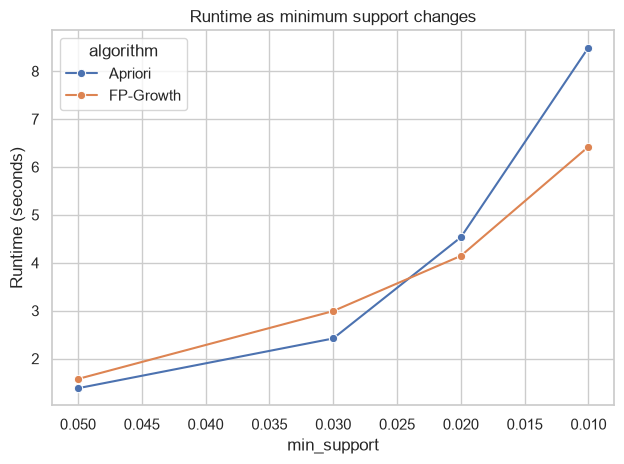

algorithm,Apriori,FP-Growth,same_count
min_support,,,
0.01,49684,49684,True
0.02,28026,28026,True
0.03,19093,19093,True
0.05,10476,10476,True


In [12]:
supports = (0.05, 0.03, 0.02, 0.01)
timing_rows = []
for support in supports:
    start = time.perf_counter()
    apriori_items = apriori(encoded_train, min_support=support, use_colnames=True, max_len=4)
    apriori_seconds = time.perf_counter() - start

    start = time.perf_counter()
    fpgrowth_items = fpgrowth(encoded_train, min_support=support, use_colnames=True, max_len=4)
    fpgrowth_seconds = time.perf_counter() - start

    same_count = len(apriori_items) == len(fpgrowth_items)
    timing_rows.extend([
        {'min_support': support, 'algorithm': 'Apriori', 'seconds': apriori_seconds, 'itemsets': len(apriori_items)},
        {'min_support': support, 'algorithm': 'FP-Growth', 'seconds': fpgrowth_seconds, 'itemsets': len(fpgrowth_items)},
    ])
    print(f'{support:.2f}: same itemset count = {same_count}; count = {len(apriori_items)}')

timings = pd.DataFrame(timing_rows)
sns.lineplot(data=timings, x='min_support', y='seconds', hue='algorithm', marker='o')
plt.gca().invert_xaxis()
plt.ylabel('Runtime (seconds)')
plt.title('Runtime as minimum support changes')
plt.tight_layout()
plt.show()

itemset_check = timings.pivot(index='min_support', columns='algorithm', values='itemsets')
display(itemset_check.assign(same_count=itemset_check['Apriori'] == itemset_check['FP-Growth']))

### Observation and decision
Both algorithms should return the same frequent itemsets at each support threshold; the check above tests that implementation detail directly. Lower support usually means more itemsets and more work. The runtime plot shows which algorithm is faster on this dataset rather than assuming the answer from theory alone.

## How the algorithms work, in student language

- **Anti-monotone support:** if a group of items is too rare, adding more items cannot make it common. Therefore, if `{contact=telephone, month=dec}` is below the support threshold, every larger combination containing it can be ignored.
- **Apriori:** it first finds frequent one-item groups, joins them to make candidate pairs, scans the baskets, then makes larger candidates and scans again. The repeated candidate generation and data scans can become expensive.
- **FP-Growth:** it compresses the baskets into an FP-tree and mines shared prefixes. It avoids explicitly generating every candidate combination, so it often needs fewer scans.
- **DHP:** the Direct Hashing and Pruning method would add hash tables while counting early candidates. Buckets whose counts are too small can be pruned before Apriori creates larger candidates, reducing the candidate list.

### Observation and decision
For this project, FP-Growth is a useful default because it avoids candidate generation while preserving the same support definition. Apriori remains valuable as a transparent comparison and as a way to explain the anti-monotone pruning idea.

## Top 10 rules in manager language

In [13]:
BASE_RATE = 0.117

def item_text(item):
    column, value = item.split('=', maxsplit=1)
    return f'{column.replace("_", " " )} is {value}'


manager_sentences = []
for _, rule in subscription_rules.head(10).iterrows():
    antecedent = sorted(rule['antecedents'])
    description = ' and '.join(item_text(item) for item in antecedent)
    support = rule['support']
    confidence = rule['confidence']
    lift = rule['lift']
    comparison = 'above' if confidence > BASE_RATE else 'not above'
    warning = ' This is rare, so use it as a hypothesis rather than a standalone campaign rule.' if support < 0.02 else ''
    sentence = (
        f'Prioritise clients where {description}: {confidence:.1%} subscribed, '
        f'the rule covers {support:.1%} of training clients and has lift {lift:.2f}; '
        f'confidence is {comparison} the {BASE_RATE:.1%} base rate.' + warning
    )
    manager_sentences.append(sentence)

for number, sentence in enumerate(manager_sentences, start=1):
    print(f'{number}. {sentence}')

print('Rules with support below 2% are flagged as too rare for a standalone campaign decision.')
print('Rules that repeat an obvious target-related pattern should be treated as confirmation, not a new policy.')

1. Prioritise clients where housing is no and pdays is 90+ and poutcome is success: 70.6% subscribed, the rule covers 1.4% of training clients and has lift 6.03; confidence is above the 11.7% base rate. This is rare, so use it as a hypothesis rather than a standalone campaign rule.
2. Prioritise clients where contact is cellular and housing is no and poutcome is success: 70.2% subscribed, the rule covers 1.5% of training clients and has lift 6.00; confidence is above the 11.7% base rate. This is rare, so use it as a hypothesis rather than a standalone campaign rule.
3. Prioritise clients where housing is no and loan is no and poutcome is success: 70.2% subscribed, the rule covers 1.6% of training clients and has lift 6.00; confidence is above the 11.7% base rate. This is rare, so use it as a hypothesis rather than a standalone campaign rule.
4. Prioritise clients where default is no and housing is no and poutcome is success: 70.0% subscribed, the rule covers 1.6% of training clients an

### Observation and decision
A manager should use these rules to prioritise a conversation, not to promise a subscription. Confidence above 11.7% is better than the baseline, but low-support rules may describe too few clients to be reliable. Rules that simply restate a very strong known pattern are obvious and should support, rather than replace, the validated scoring model.

In [14]:
import json

from sklearn.tree import DecisionTreeClassifier, export_text

from src.pipeline import build

# Save the ten strongest subscription rules in the API contract format.
insight_rules = []
for _, rule in subscription_rules.head(10).iterrows():
    items = sorted(rule['antecedents'])
    item_text = ' and '.join(items)
    insight_rules.append({
        'if': items,
        'support': float(rule['support']),
        'confidence': float(rule['confidence']),
        'lift': float(rule['lift']),
        'text': (
            f'Prioritise clients where {item_text}: '
            f'{rule["confidence"]:.1%} subscribed.'
        ),
    })

# Fit the explainable tree through the same preprocessing pipeline as the model.
tree_pipeline = build(
    DecisionTreeClassifier(
        criterion='gini',
        max_depth=4,
        min_samples_leaf=100,
        class_weight='balanced',
        random_state=42,
    )
)
tree_pipeline.fit(X_train, y_train)
feature_names = tree_pipeline.named_steps['prep'].get_feature_names_out()
tree_text = export_text(
    tree_pipeline.named_steps['model'],
    feature_names=list(feature_names),
)

insights_path = PROJECT_ROOT / 'models' / 'insights.json'
insights_path.write_text(
    json.dumps({'rules': insight_rules, 'tree_text': tree_text}, indent=2) + '\n'
)
print(f'Wrote {len(insight_rules)} rules and the decision tree to {insights_path}')

Wrote 10 rules and the decision tree to d:\fdm\models\insights.json
